In [1]:
!pip install pyspark
print("PySpark installed ✅")

PySpark installed ✅


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, when, corr
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
spark = SparkSession.builder \
    .appName("PredictiveMaintenance") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark Session started ✅")

Spark version: 4.0.2
Spark Session started ✅


In [5]:
from google.colab import files
uploaded = files.upload()  # Select and upload ai4i2020.csv from your computer

Saving ai4i2020.csv to ai4i2020.csv


In [6]:
import os
print(os.listdir("/content/"))

['.config', 'ai4i2020.csv', 'sample_data']


In [7]:
df_spark = spark.read.csv(
    "/content/ai4i2020.csv",    # ← Add /content/ before filename
    header=True,
    inferSchema=True
)

In [8]:
df_spark = spark.read.csv(
    "ai4i2020.csv",
    header=True,
    inferSchema=True
)

print("Shape: ({}, {})".format(df_spark.count(), len(df_spark.columns)))
df_spark.printSchema()

Shape: (10000, 14)
root
 |-- UDI: integer (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Air temperature [K]: double (nullable = true)
 |-- Process temperature [K]: double (nullable = true)
 |-- Rotational speed [rpm]: integer (nullable = true)
 |-- Torque [Nm]: double (nullable = true)
 |-- Tool wear [min]: integer (nullable = true)
 |-- Machine failure: integer (nullable = true)
 |-- TWF: integer (nullable = true)
 |-- HDF: integer (nullable = true)
 |-- PWF: integer (nullable = true)
 |-- OSF: integer (nullable = true)
 |-- RNF: integer (nullable = true)



In [9]:
# Show first 5 rows
df_spark.show(5, truncate=False)

# Summary statistics
df_spark.describe().show()

+---+----------+----+-------------------+-----------------------+----------------------+-----------+---------------+---------------+---+---+---+---+---+
|UDI|Product ID|Type|Air temperature [K]|Process temperature [K]|Rotational speed [rpm]|Torque [Nm]|Tool wear [min]|Machine failure|TWF|HDF|PWF|OSF|RNF|
+---+----------+----+-------------------+-----------------------+----------------------+-----------+---------------+---------------+---+---+---+---+---+
|1  |M14860    |M   |298.1              |308.6                  |1551                  |42.8       |0              |0              |0  |0  |0  |0  |0  |
|2  |L47181    |L   |298.2              |308.7                  |1408                  |46.3       |3              |0              |0  |0  |0  |0  |0  |
|3  |L47182    |L   |298.1              |308.5                  |1498                  |49.4       |5              |0              |0  |0  |0  |0  |0  |
|4  |L47183    |L   |298.2              |308.6                  |1433             

In [10]:
df_spark = df_spark.drop('UDI', 'Product ID')
print("Columns remaining:", df_spark.columns)

Columns remaining: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [11]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="Type", outputCol="Type_Index")
df_spark = indexer.fit(df_spark).transform(df_spark)
df_spark = df_spark.drop("Type")

print("Type column encoded ✅")
df_spark.show(3)

Type column encoded ✅
+-------------------+-----------------------+----------------------+-----------+---------------+---------------+---+---+---+---+---+----------+
|Air temperature [K]|Process temperature [K]|Rotational speed [rpm]|Torque [Nm]|Tool wear [min]|Machine failure|TWF|HDF|PWF|OSF|RNF|Type_Index|
+-------------------+-----------------------+----------------------+-----------+---------------+---------------+---+---+---+---+---+----------+
|              298.1|                  308.6|                  1551|       42.8|              0|              0|  0|  0|  0|  0|  0|       1.0|
|              298.2|                  308.7|                  1408|       46.3|              3|              0|  0|  0|  0|  0|  0|       0.0|
|              298.1|                  308.5|                  1498|       49.4|              5|              0|  0|  0|  0|  0|  0|       0.0|
+-------------------+-----------------------+----------------------+-----------+---------------+---------------+--

In [12]:
from pyspark.sql.functions import col

df_spark = df_spark.withColumn(
    "Power",
    col("Rotational speed [rpm]") * col("Torque [Nm]")
)

df_spark = df_spark.withColumn(
    "Temp_diff",
    col("Process temperature [K]") - col("Air temperature [K]")
)

print("New features added ✅")
df_spark.select("Power", "Temp_diff").show(5)

New features added ✅
+------------------+------------------+
|             Power|         Temp_diff|
+------------------+------------------+
| 66382.79999999999|              10.5|
|65190.399999999994|              10.5|
|           74001.2|10.399999999999977|
|           56603.5|10.400000000000034|
|           56320.0|              10.5|
+------------------+------------------+
only showing top 5 rows


In [13]:
# 1. Average sensor readings by failure status
print("=== Avg Sensor Readings by Failure ===")
df_spark.groupBy("Machine failure").agg(
    avg("Air temperature [K]").alias("Avg_Air_Temp"),
    avg("Process temperature [K]").alias("Avg_Process_Temp"),
    avg("Rotational speed [rpm]").alias("Avg_Speed"),
    avg("Torque [Nm]").alias("Avg_Torque"),
    avg("Tool wear [min]").alias("Avg_Tool_Wear"),
    count("*").alias("Count")
).show()

=== Avg Sensor Readings by Failure ===
+---------------+-----------------+-----------------+------------------+------------------+------------------+-----+
|Machine failure|     Avg_Air_Temp| Avg_Process_Temp|         Avg_Speed|        Avg_Torque|     Avg_Tool_Wear|Count|
+---------------+-----------------+-----------------+------------------+------------------+------------------+-----+
|              0|299.9739985508732|309.9955698167888|1540.2600144912535| 39.62965531518476|106.69371700652107| 9661|
|              1| 300.886430678466|310.2902654867255| 1496.486725663717|50.168141592920364|143.78171091445427|  339|
+---------------+-----------------+-----------------+------------------+------------------+------------------+-----+



In [14]:
# 2. Failure rate by machine type
print("=== Failure Rate by Machine Type ===")
df_spark.groupBy("Type_Index").agg(
    count("*").alias("Total"),
    count(when(col("Machine failure") == 1, 1)).alias("Failures")
).withColumn(
    "Failure_Rate_%",
    (col("Failures") / col("Total") * 100)
).show()

=== Failure Rate by Machine Type ===
+----------+-----+--------+------------------+
|Type_Index|Total|Failures|    Failure_Rate_%|
+----------+-----+--------+------------------+
|       0.0| 6000|     235| 3.916666666666667|
|       1.0| 2997|      83|2.7694361027694363|
|       2.0| 1003|      21|2.0937188434695915|
+----------+-----+--------+------------------+



In [15]:
# 3. High risk records — high torque AND high tool wear
print("=== High Risk Machines ===")
high_risk = df_spark.filter(
    (col("Torque [Nm]") > 60) & (col("Tool wear [min]") > 200)
)
print("High risk count:", high_risk.count())
high_risk.show(5)

=== High Risk Machines ===
High risk count: 18
+-------------------+-----------------------+----------------------+-----------+---------------+---------------+---+---+---+---+---+----------+-----------------+-----------------+
|Air temperature [K]|Process temperature [K]|Rotational speed [rpm]|Torque [Nm]|Tool wear [min]|Machine failure|TWF|HDF|PWF|OSF|RNF|Type_Index|            Power|        Temp_diff|
+-------------------+-----------------------+----------------------+-----------+---------------+---------------+---+---+---+---+---+----------+-----------------+-----------------+
|              298.4|                  308.2|                  1282|       60.7|            216|              1|  0|  0|  0|  1|  0|       0.0|77817.40000000001|9.800000000000011|
|              299.8|                  309.3|                  1299|       65.1|            212|              1|  0|  0|  0|  1|  0|       0.0|          84564.9|              9.5|
|              302.3|                  311.4|        

In [16]:
# 4. Correlation between Power and Failure
print("=== Correlation: Power vs Failure ===")
corr_val = df_spark.stat.corr("Power", "Machine failure")
print(f"Correlation: {corr_val:.4f}")

=== Correlation: Power vs Failure ===
Correlation: 0.1760


/tmp/ipykernel_9035/712217383.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y='Torque [Nm]', data=pdf, palette='Set2')


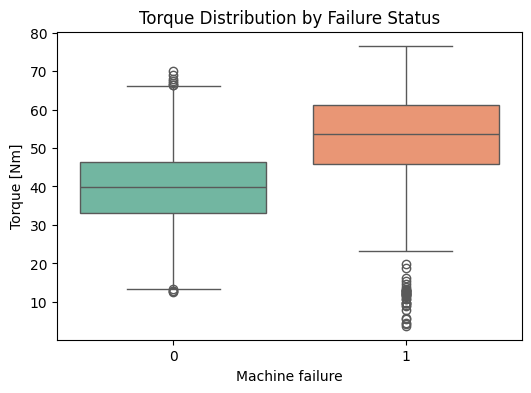

/tmp/ipykernel_9035/712217383.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y='Tool wear [min]', data=pdf, palette='muted')


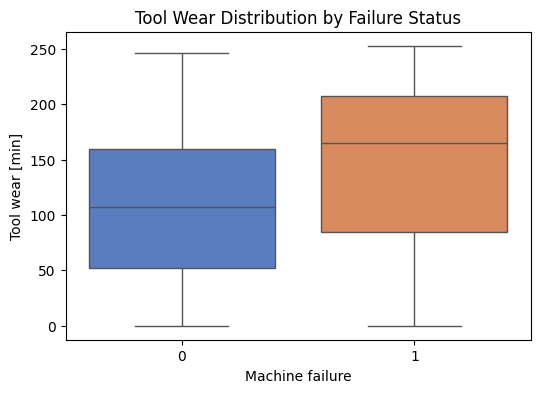

In [17]:
# Convert Spark DF to Pandas for visualization
pdf = df_spark.toPandas()

# Plot avg torque by failure
plt.figure(figsize=(6,4))
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=pdf, palette='Set2')
plt.title("Torque Distribution by Failure Status")
plt.show()

# Plot tool wear by failure
plt.figure(figsize=(6,4))
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=pdf, palette='muted')
plt.title("Tool Wear Distribution by Failure Status")
plt.show()

In [18]:
# Save for Tableau & Power BI later
pdf.to_csv("spark_processed_data.csv", index=False)
print("Spark processed data saved ✅")
print("Shape:", pdf.shape)

Spark processed data saved ✅
Shape: (10000, 14)


In [19]:
spark.stop()
print("Spark session stopped ✅")

Spark session stopped ✅
